In [1]:
from src.dataset import DigitAnomalyDataset
from src.encoders import PCAAngleEncoder, AmplitudeEncoder
from src.feature_map import AngleFeatureMap, AmplitudeFeatureMap
from src.kernel import FidelityQuantumKernel, ClassicalRBFKernel
from src.models import OneClassSVMAnomalyModel
from src.anomaly_eval import AnomalyEvaluator
from src.visualizer import AnomalyVisualizer
from src.experiment import QuantumAnomalyExperiment
import pandas as pd

In [2]:
def run_all_four_methods(
    dataset,
    pca_components=4,
    reps=2,
    nu=0.1,
    threshold_strategy="expected_fraction",
    verbose=False,
    plot_best=False,
):
    """
    Run all 4 combinations:

        1. PCA encoder       + quantum angle kernel
        2. Amplitude encoder + quantum fidelity kernel
        3. PCA encoder       + classical RBF kernel
        4. Amplitude encoder + classical RBF kernel

    Returns
    -------
    comparison : pandas.DataFrame
        Summary table of metrics.

    results : dict
        Full result dictionaries for each method.

    experiments : dict
        Experiment objects, useful for plotting/debugging.
    """

    methods = {
        "PCA + Quantum Angle Kernel": {
            "encoder": PCAAngleEncoder(n_components=pca_components),
            "kernel": FidelityQuantumKernel(
                feature_map=AngleFeatureMap(reps=reps)
            ),
        },

        "Amplitude + Quantum Fidelity Kernel": {
            "encoder": AmplitudeEncoder(n_qubits=6),
            "kernel": FidelityQuantumKernel(
                feature_map=AmplitudeFeatureMap()
            ),
        },

        "PCA + Classical RBF Kernel": {
            "encoder": PCAAngleEncoder(n_components=pca_components),
            "kernel": ClassicalRBFKernel(gamma="scale"),
        },

        "Amplitude + Classical RBF Kernel": {
            "encoder": AmplitudeEncoder(n_qubits=6),
            "kernel": ClassicalRBFKernel(gamma="scale"),
        },
    }

    results = {}
    experiments = {}
    rows = []

    for method_name, components in methods.items():
        exp = QuantumAnomalyExperiment(
            name=method_name,
            dataset=dataset,
            encoder=components["encoder"],
            kernel=components["kernel"],
            model=OneClassSVMAnomalyModel(nu=nu),
            evaluator=AnomalyEvaluator(threshold_strategy=threshold_strategy),
            visualizer=AnomalyVisualizer(),
        )

        result = exp.run(verbose=verbose)

        results[method_name] = result
        experiments[method_name] = exp

        metrics = result["metrics"]
        encoder_info = result.get("encoder_info", {})
        kernel_info = result.get("kernel_info", {})

        row = {
            "method": method_name,
            "encoder": encoder_info.get("type", "unknown"),
            "kernel": kernel_info.get("type", "unknown"),
            "auc": metrics["auc"],
            "f1": metrics["f1"],
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "threshold": metrics["threshold"],
        }

        if encoder_info.get("type") == "pca_angle":
            row["encoded_dim"] = encoder_info.get("n_components")
            row["qubits_or_features"] = encoder_info.get("n_components")
            row["explained_variance"] = encoder_info.get("total_explained_variance")

        elif encoder_info.get("type") == "amplitude":
            row["encoded_dim"] = encoder_info.get("state_dim")
            row["qubits_or_features"] = encoder_info.get("n_qubits")
            row["explained_variance"] = None

        else:
            row["encoded_dim"] = None
            row["qubits_or_features"] = None
            row["explained_variance"] = None

        rows.append(row)

    comparison = pd.DataFrame(rows)
    comparison = comparison.sort_values("auc", ascending=False).reset_index(drop=True)

    print("\n===== Comparison Table =====")
    display(comparison)

    if plot_best:
        best_method = comparison.iloc[0]["method"]
        print(f"\nPlotting best method: {best_method}")
        experiments[best_method].plot_results()

    return comparison, results, experiments

In [3]:
dataset = DigitAnomalyDataset(
    normal_digit=0,
    anomaly_digits=[1, 2, 3, 4, 5, 6, 7, 8, 9],
    n_train_normal=120,
    n_test_normal=10,
    n_test_anomaly=10,
    random_state=7,
)

comparison, results, experiments = run_all_four_methods(
    dataset=dataset,
    pca_components=4,
    reps=2,
    nu=0.1,
    verbose=False,
    plot_best=False,
)

qiskit_runtime_service.__init__:WARNING:2026-06-02 11:56:55,419: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (on-prem), the available account instances are: Hackathon IQUCodeFest Juin 2026. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-02 11:56:55,832: Loading instance: Hackathon IQUCodeFest Juin 2026, plan: on-prem
qiskit_runtime_service.backends:WARNING:2026-06-02 11:56:56,213: Using instance: Hackathon IQUCodeFest Juin 2026, plan: on-prem


Selected backend: ibm_quebec


qiskit_runtime_service.__init__:WARNING:2026-06-02 11:57:03,928: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (on-prem), the available account instances are: Hackathon IQUCodeFest Juin 2026. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-02 11:57:04,226: Loading instance: Hackathon IQUCodeFest Juin 2026, plan: on-prem
qiskit_runtime_service.backends:WARNING:2026-06-02 11:57:04,627: Using instance: Hackathon IQUCodeFest Juin 2026, plan: on-prem


Selected backend: ibm_quebec


qiskit_runtime_service.__init__:WARNING:2026-06-02 11:57:11,244: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (on-prem), the available account instances are: Hackathon IQUCodeFest Juin 2026. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-02 11:57:11,730: Loading instance: Hackathon IQUCodeFest Juin 2026, plan: on-prem
qiskit_runtime_service.backends:WARNING:2026-06-02 11:57:12,199: Using instance: Hackathon IQUCodeFest Juin 2026, plan: on-prem


Selected backend: ibm_quebec


qiskit_runtime_service.__init__:WARNING:2026-06-02 11:57:23,096: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (on-prem), the available account instances are: Hackathon IQUCodeFest Juin 2026. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-02 11:57:23,392: Loading instance: Hackathon IQUCodeFest Juin 2026, plan: on-prem
qiskit_runtime_service.backends:WARNING:2026-06-02 11:57:23,610: Using instance: Hackathon IQUCodeFest Juin 2026, plan: on-prem


Selected backend: ibm_quebec

===== Comparison Table =====


/home/samuel/IQcodefest_Stagiaires/src/kernel.py:419: ComplexWarning: Casting complex values to real discards the imaginary part
  X_train = np.asarray(X_train, dtype=float)
/home/samuel/IQcodefest_Stagiaires/src/kernel.py:430: ComplexWarning: Casting complex values to real discards the imaginary part
  X_test = np.asarray(X_test, dtype=float)


,method,encoder,kernel,auc,f1,precision,recall,threshold,encoded_dim,qubits_or_features,explained_variance
0,Amplitude + Classical RBF Kernel,amplitude,classical_rbf_kernel,1.0,1.000000,1.0,1.0,0.404938,64,6,NaN
1,PCA + Classical RBF Kernel,pca_angle,classical_rbf_kernel,1.0,1.000000,1.0,1.0,0.179899,4,4,0.491227
2,Amplitude + Quantum Fidelity Kernel,amplitude,fidelity_quantum_kernel,0.5,0.666667,0.5,1.0,-0.000000,64,6,NaN
3,PCA + Quantum Angle Kernel,pca_angle,fidelity_quantum_kernel,0.5,0.666667,0.5,1.0,-0.000000,4,4,0.491227


In [4]:
dataset = DigitAnomalyDataset(
    normal_digit=0,
    anomaly_digits=[6, 9],
    n_train_normal=120,
    n_test_normal=10,
    n_test_anomaly=10,
    random_state=7,
)

comparison, results, experiments = run_all_four_methods(
    dataset=dataset,
    pca_components=4,
    reps=2,
    nu=0.1,
    verbose=False,
    plot_best=False,
)

qiskit_runtime_service.__init__:WARNING:2026-06-02 11:57:29,964: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (on-prem), the available account instances are: Hackathon IQUCodeFest Juin 2026. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-02 11:57:30,249: Loading instance: Hackathon IQUCodeFest Juin 2026, plan: on-prem
qiskit_runtime_service.backends:WARNING:2026-06-02 11:57:30,593: Using instance: Hackathon IQUCodeFest Juin 2026, plan: on-prem


Selected backend: ibm_quebec


qiskit_runtime_service.__init__:WARNING:2026-06-02 11:57:42,427: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (on-prem), the available account instances are: Hackathon IQUCodeFest Juin 2026. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-02 11:57:42,800: Loading instance: Hackathon IQUCodeFest Juin 2026, plan: on-prem
qiskit_runtime_service.backends:WARNING:2026-06-02 11:57:43,269: Using instance: Hackathon IQUCodeFest Juin 2026, plan: on-prem


Selected backend: ibm_quebec


qiskit_runtime_service.__init__:WARNING:2026-06-02 11:57:47,410: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (on-prem), the available account instances are: Hackathon IQUCodeFest Juin 2026. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-02 11:57:47,801: Loading instance: Hackathon IQUCodeFest Juin 2026, plan: on-prem
qiskit_runtime_service.backends:WARNING:2026-06-02 11:57:48,209: Using instance: Hackathon IQUCodeFest Juin 2026, plan: on-prem


Selected backend: ibm_quebec


qiskit_runtime_service.__init__:WARNING:2026-06-02 11:57:59,035: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (on-prem), the available account instances are: Hackathon IQUCodeFest Juin 2026. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-02 11:57:59,652: Loading instance: Hackathon IQUCodeFest Juin 2026, plan: on-prem
qiskit_runtime_service.backends:WARNING:2026-06-02 11:58:04,690: Using instance: Hackathon IQUCodeFest Juin 2026, plan: on-prem


Selected backend: ibm_quebec

===== Comparison Table =====


/home/samuel/IQcodefest_Stagiaires/src/kernel.py:419: ComplexWarning: Casting complex values to real discards the imaginary part
  X_train = np.asarray(X_train, dtype=float)
/home/samuel/IQcodefest_Stagiaires/src/kernel.py:430: ComplexWarning: Casting complex values to real discards the imaginary part
  X_test = np.asarray(X_test, dtype=float)


,method,encoder,kernel,auc,f1,precision,recall,threshold,encoded_dim,qubits_or_features,explained_variance
0,Amplitude + Classical RBF Kernel,amplitude,classical_rbf_kernel,1.00,1.000000,1.0,1.0,0.317203,64,6,NaN
1,PCA + Classical RBF Kernel,pca_angle,classical_rbf_kernel,0.93,0.800000,0.8,0.8,0.034022,4,4,0.491227
2,Amplitude + Quantum Fidelity Kernel,amplitude,fidelity_quantum_kernel,0.50,0.666667,0.5,1.0,-0.000000,64,6,NaN
3,PCA + Quantum Angle Kernel,pca_angle,fidelity_quantum_kernel,0.50,0.666667,0.5,1.0,-0.000000,4,4,0.491227


In [5]:
dataset = DigitAnomalyDataset(
    normal_digit=1,
    anomaly_digits=[7],
    n_train_normal=120,
    n_test_normal=10,
    n_test_anomaly=10,
    random_state=7,
)

comparison, results, experiments = run_all_four_methods(
    dataset=dataset,
    pca_components=4,
    reps=2,
    nu=0.1,
    verbose=False,
    plot_best=False,
)

qiskit_runtime_service.__init__:WARNING:2026-06-02 11:58:10,609: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (on-prem), the available account instances are: Hackathon IQUCodeFest Juin 2026. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-02 11:58:11,137: Loading instance: Hackathon IQUCodeFest Juin 2026, plan: on-prem
qiskit_runtime_service.backends:WARNING:2026-06-02 11:58:12,693: Using instance: Hackathon IQUCodeFest Juin 2026, plan: on-prem


Selected backend: ibm_quebec


qiskit_runtime_service.__init__:WARNING:2026-06-02 11:58:17,088: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (on-prem), the available account instances are: Hackathon IQUCodeFest Juin 2026. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-02 11:58:17,487: Loading instance: Hackathon IQUCodeFest Juin 2026, plan: on-prem
qiskit_runtime_service.backends:WARNING:2026-06-02 11:58:17,850: Using instance: Hackathon IQUCodeFest Juin 2026, plan: on-prem


Selected backend: ibm_quebec


qiskit_runtime_service.__init__:WARNING:2026-06-02 11:58:22,789: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (on-prem), the available account instances are: Hackathon IQUCodeFest Juin 2026. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-02 11:58:23,140: Loading instance: Hackathon IQUCodeFest Juin 2026, plan: on-prem
qiskit_runtime_service.backends:WARNING:2026-06-02 11:58:23,711: Using instance: Hackathon IQUCodeFest Juin 2026, plan: on-prem


Selected backend: ibm_quebec


qiskit_runtime_service.__init__:WARNING:2026-06-02 11:58:34,108: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (on-prem), the available account instances are: Hackathon IQUCodeFest Juin 2026. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-02 11:58:34,236: Loading instance: Hackathon IQUCodeFest Juin 2026, plan: on-prem
qiskit_runtime_service.backends:WARNING:2026-06-02 11:58:34,630: Using instance: Hackathon IQUCodeFest Juin 2026, plan: on-prem


Selected backend: ibm_quebec

===== Comparison Table =====


/home/samuel/IQcodefest_Stagiaires/src/kernel.py:419: ComplexWarning: Casting complex values to real discards the imaginary part
  X_train = np.asarray(X_train, dtype=float)
/home/samuel/IQcodefest_Stagiaires/src/kernel.py:430: ComplexWarning: Casting complex values to real discards the imaginary part
  X_test = np.asarray(X_test, dtype=float)


,method,encoder,kernel,auc,f1,precision,recall,threshold,encoded_dim,qubits_or_features,explained_variance
0,Amplitude + Classical RBF Kernel,amplitude,classical_rbf_kernel,0.99,0.900000,0.9,0.9,0.534114,64,6,NaN
1,PCA + Quantum Angle Kernel,pca_angle,fidelity_quantum_kernel,0.50,0.666667,0.5,1.0,-0.000000,4,4,0.5993
2,Amplitude + Quantum Fidelity Kernel,amplitude,fidelity_quantum_kernel,0.50,0.666667,0.5,1.0,-0.000000,64,6,NaN
3,PCA + Classical RBF Kernel,pca_angle,classical_rbf_kernel,0.38,0.400000,0.4,0.4,-0.206139,4,4,0.5993


In [6]:
dataset = DigitAnomalyDataset(
    normal_digit=3,
    anomaly_digits=[8],
    n_train_normal=120,
    n_test_normal=10,
    n_test_anomaly=10,
    random_state=7,
)

comparison, results, experiments = run_all_four_methods(
    dataset=dataset,
    pca_components=4,
    reps=2,
    nu=0.1,
    verbose=False,
    plot_best=False,
)

qiskit_runtime_service.__init__:WARNING:2026-06-02 11:58:39,589: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (on-prem), the available account instances are: Hackathon IQUCodeFest Juin 2026. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-02 11:58:39,701: Loading instance: Hackathon IQUCodeFest Juin 2026, plan: on-prem
qiskit_runtime_service.backends:WARNING:2026-06-02 11:58:40,407: Using instance: Hackathon IQUCodeFest Juin 2026, plan: on-prem


Selected backend: ibm_quebec


qiskit_runtime_service.__init__:WARNING:2026-06-02 11:58:47,965: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (on-prem), the available account instances are: Hackathon IQUCodeFest Juin 2026. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-02 11:58:48,287: Loading instance: Hackathon IQUCodeFest Juin 2026, plan: on-prem
qiskit_runtime_service.backends:WARNING:2026-06-02 11:58:48,508: Using instance: Hackathon IQUCodeFest Juin 2026, plan: on-prem


Selected backend: ibm_quebec


qiskit_runtime_service.__init__:WARNING:2026-06-02 11:58:55,661: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (on-prem), the available account instances are: Hackathon IQUCodeFest Juin 2026. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-02 11:58:55,833: Loading instance: Hackathon IQUCodeFest Juin 2026, plan: on-prem
qiskit_runtime_service.backends:WARNING:2026-06-02 11:58:56,818: Using instance: Hackathon IQUCodeFest Juin 2026, plan: on-prem


Selected backend: ibm_quebec


qiskit_runtime_service.__init__:WARNING:2026-06-02 11:59:05,491: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (on-prem), the available account instances are: Hackathon IQUCodeFest Juin 2026. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-02 11:59:05,790: Loading instance: Hackathon IQUCodeFest Juin 2026, plan: on-prem
qiskit_runtime_service.backends:WARNING:2026-06-02 11:59:06,011: Using instance: Hackathon IQUCodeFest Juin 2026, plan: on-prem


Selected backend: ibm_quebec

===== Comparison Table =====


/home/samuel/IQcodefest_Stagiaires/src/kernel.py:419: ComplexWarning: Casting complex values to real discards the imaginary part
  X_train = np.asarray(X_train, dtype=float)
/home/samuel/IQcodefest_Stagiaires/src/kernel.py:430: ComplexWarning: Casting complex values to real discards the imaginary part
  X_test = np.asarray(X_test, dtype=float)


,method,encoder,kernel,auc,f1,precision,recall,threshold,encoded_dim,qubits_or_features,explained_variance
0,Amplitude + Classical RBF Kernel,amplitude,classical_rbf_kernel,0.91,0.800000,0.8,0.8,-0.136662,64,6,NaN
1,PCA + Classical RBF Kernel,pca_angle,classical_rbf_kernel,0.82,0.800000,0.8,0.8,-0.265755,4,4,0.472628
2,Amplitude + Quantum Fidelity Kernel,amplitude,fidelity_quantum_kernel,0.50,0.666667,0.5,1.0,-0.000000,64,6,NaN
3,PCA + Quantum Angle Kernel,pca_angle,fidelity_quantum_kernel,0.50,0.666667,0.5,1.0,-0.000000,4,4,0.472628


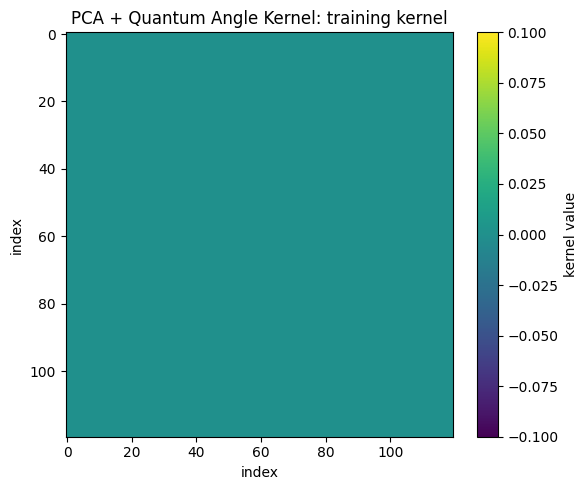

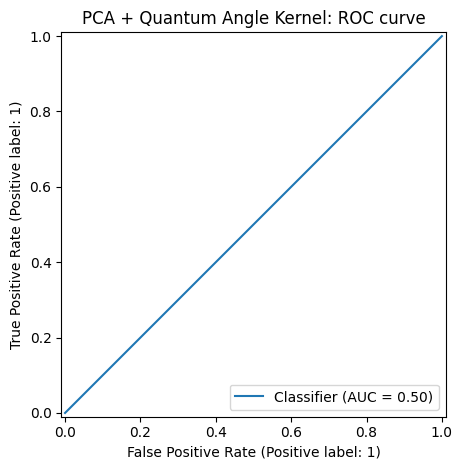

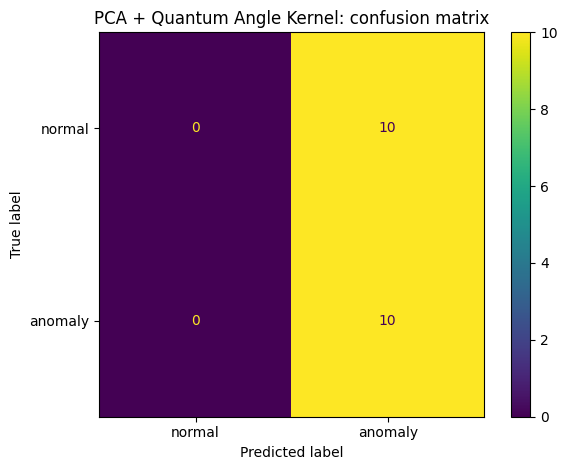

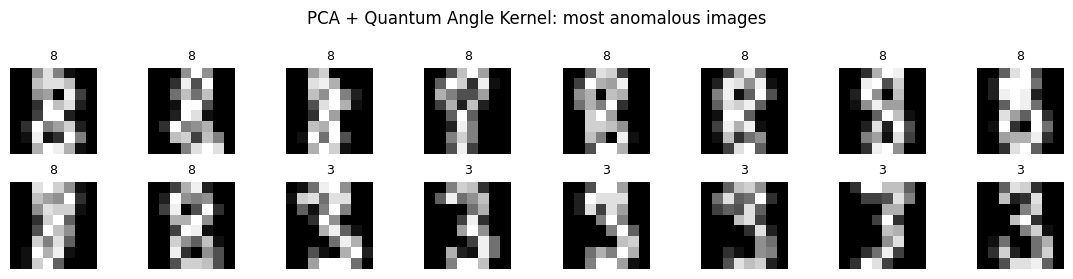

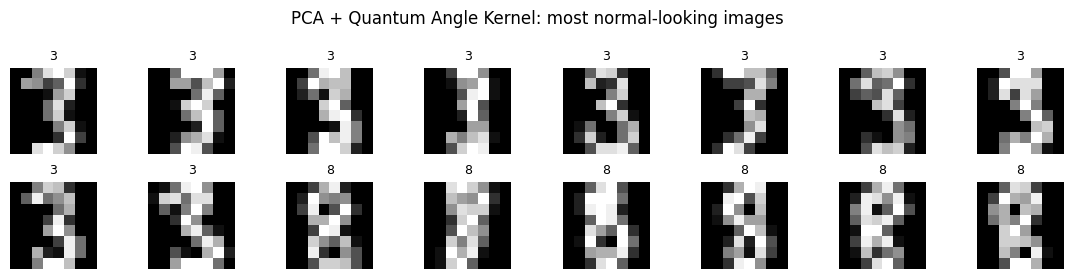

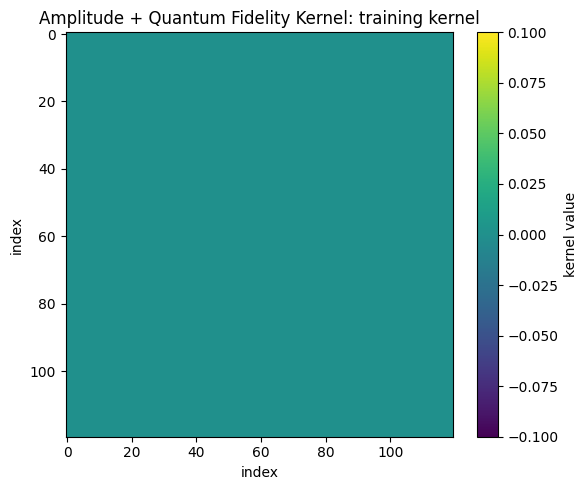

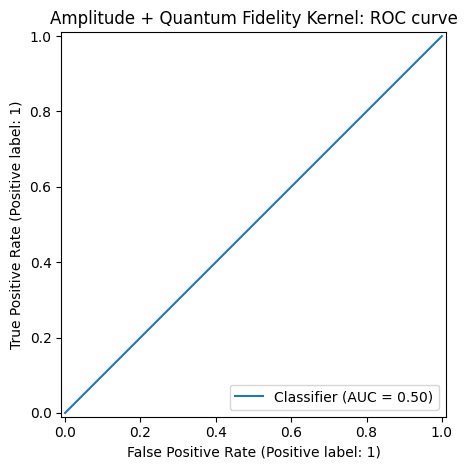

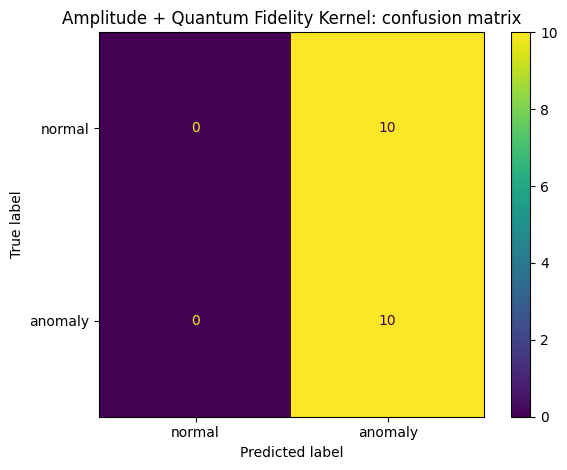

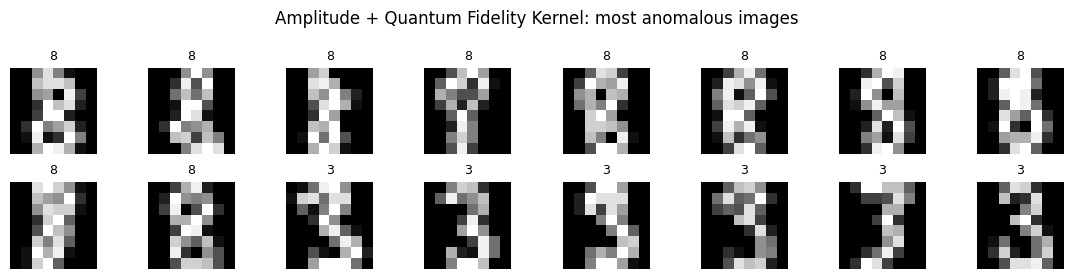

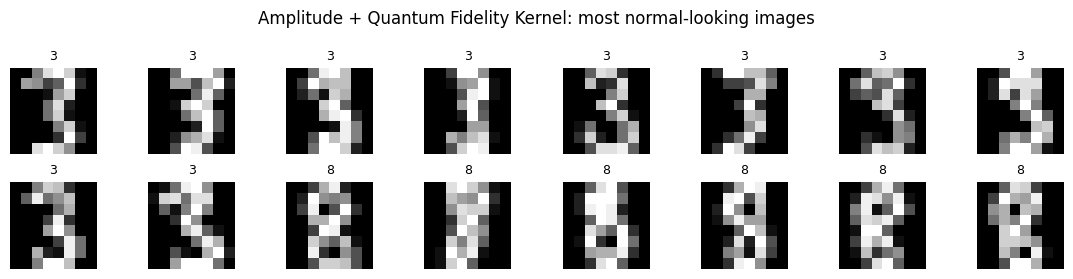

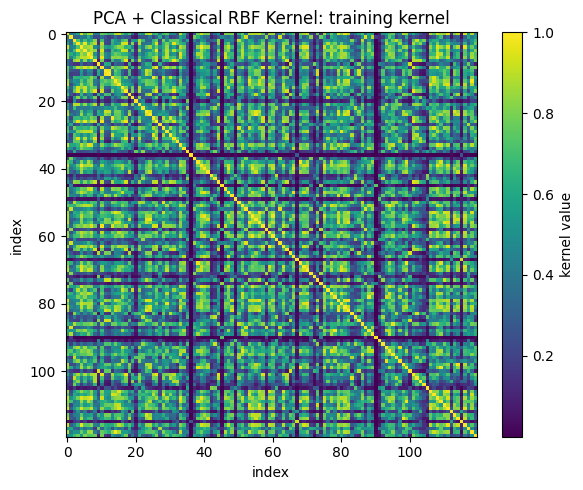

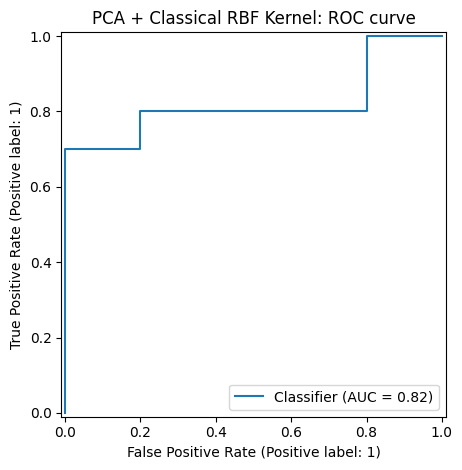

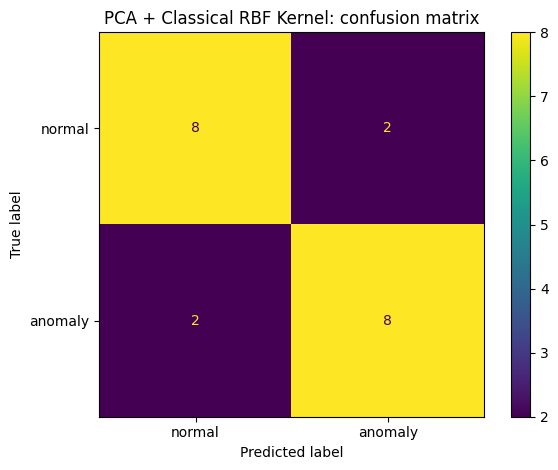

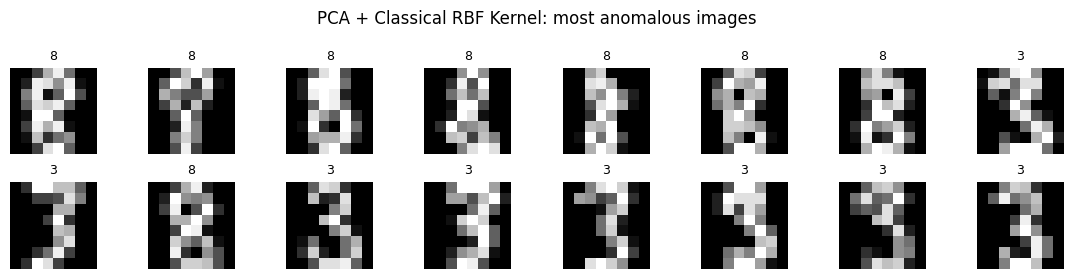

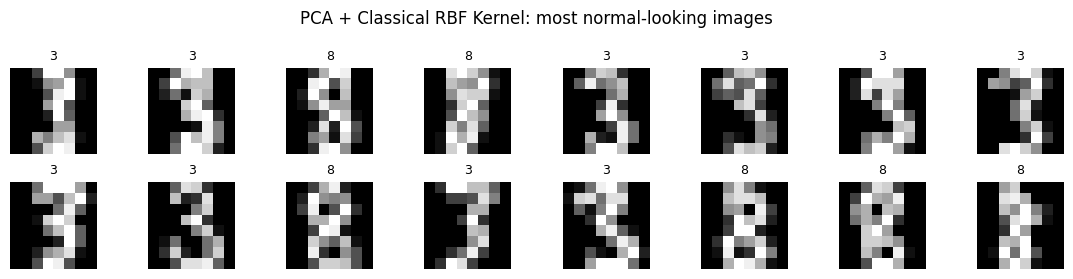

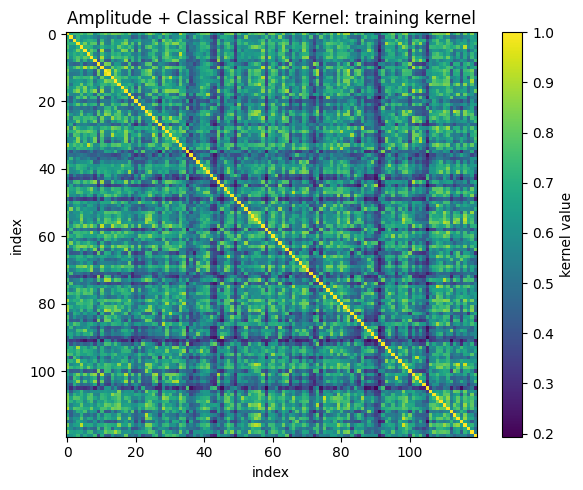

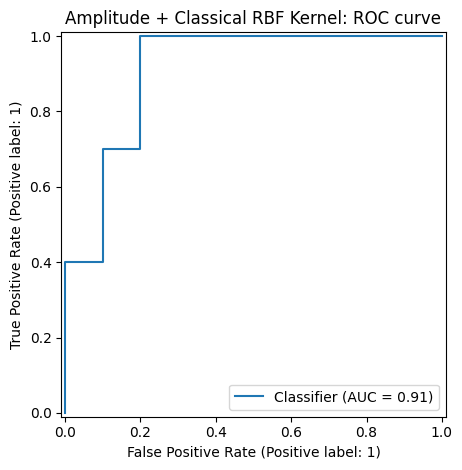

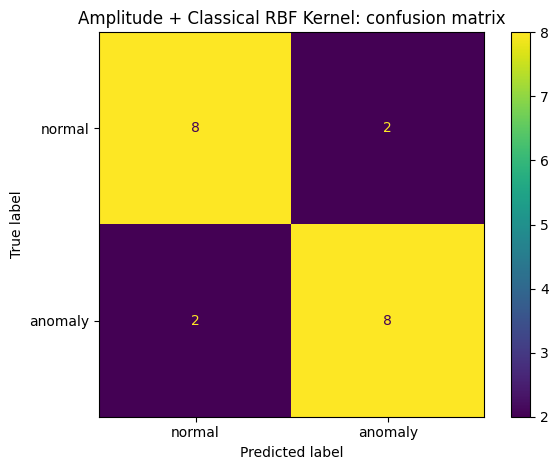

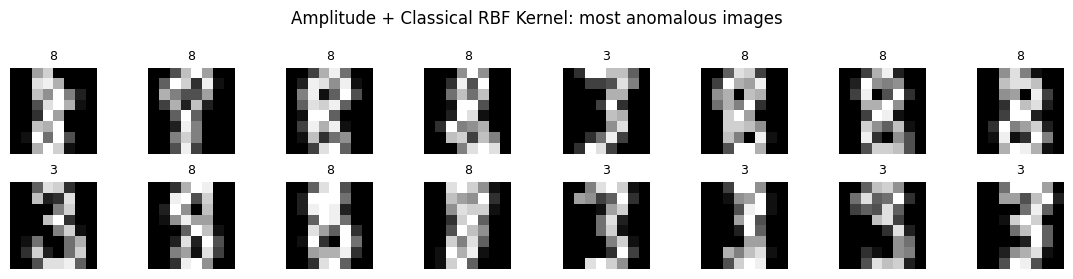

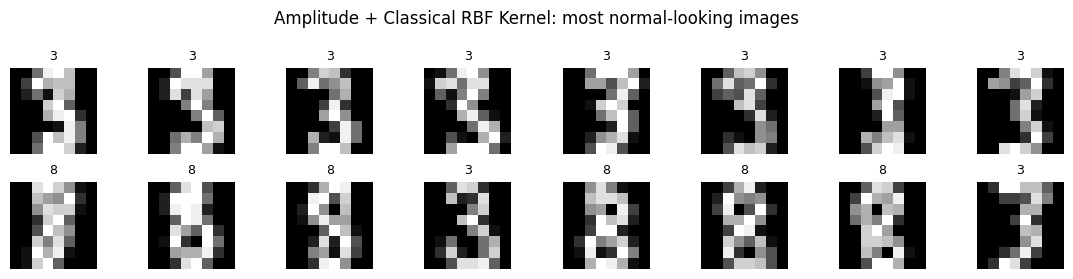

In [8]:
for k in experiments.keys():
    experiments[k].plot_results()